<font size="5">**Tarea 2**</font>

**Nombre:** José Ignacio Muñoz Barraza

<u>**Variables**</u>

Las variables tienen la siguiente descripcion:

- folio_n20:	identificacion individuo
- year:	anio 20xx
- time:	ronda de la encuesta (1-7)
- age:	edad
- hombre:	1 si hombre, 0 mujer
- edu:	educacion medida en anios completados
- region:	region (1-16)
- status:	1 casado 2 convive 3 divorciado 4 viudo 5 soltero
- kids:	1 if has kids, 0 ow
- children:	# of children under 18 years old, 18 included
- situation:	1 otro, 2 cesante, 3 trabajando, 4 inactivo
- lmp:	1 part-time worker, 2 full-time worker, 0 not working
- exp:	years of labor experience
- size:	tamanio de la firma
- occupation:	codigo ocupacion
- wage:	salario mensual en pesos del anio encuesta
- hours:	horas semanales trabajadas
- informal:	1 if no work contract, 0 ow
- selfemp:	1 if self employed, 0 ow
- publicemp:	1 if worker in public sector, 0 ow
- sistema:	1 if in AFP system, 0 ow
- cotizando:	1 if contributor, 0 ow
- assets:	accumulated wealth in pension system, pesos of each year
- exp_sist:	years of experience in pension system
- expectancy:	expectativa de vida autorreportada
- illness:	1 si tiene al menos una enferdad, 0 si no
- cronica:	Si tiene enfermedad cronica 1, 0 eoc
- nocronica:	Si tiene enfermedad no cronica 1, 0 eoc
- mental:	Si tiene enfermedad mental 1, 0 eoc

**Data:** panel_eps.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import pytwoway as tw
import bipartitepandas as bpd
import seaborn as sns
from linearmodels.iv import IV2SLS

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

<font size="3">**Pregunta 1**</font>

In [2]:
# Lectura y carga del dataframe donde están los datos
df = pd.read_csv("../data/panel_eps.csv")
df.head()   # vemos las primeras filas para ver lo que se tiene

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,fondob,fondoc,fondod,fondoe,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,NaN,NaN,NaN,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,NaN,NaN,NaN,19,75.0,NaN,NaN,NaN,NaN


In [3]:
# Para ver los tipos de datos y tener un resumen general como se hizo en la tarea anterior
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96846 entries, 0 to 96845
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   folio_n20   96846 non-null  int64  
 1   year        96846 non-null  int64  
 2   time        96846 non-null  int64  
 3   edad        96846 non-null  int64  
 4   hombre      96796 non-null  float64
 5   edu         92920 non-null  float64
 6   region      80848 non-null  float64
 7   status      96736 non-null  float64
 8   kids        96846 non-null  int64  
 9   children    78017 non-null  float64
 10  situation   96846 non-null  int64  
 11  lmp         96846 non-null  int64  
 12  exp         84869 non-null  float64
 13  size        29044 non-null  float64
 14  occupation  49777 non-null  float64
 15  wage        53897 non-null  float64
 16  hours       54576 non-null  float64
 17  informal    41259 non-null  float64
 18  selfemp     55502 non-null  float64
 19  publicemp   55502 non-nul

In [4]:
# Estadísticas descriptivas
cols_interes = ['edad', 'edu', 'expectancy', 'wage', 'hours', 'exp', 'assets']
df[cols_interes].describe()

,edad,edu,expectancy,wage,hours,exp,assets
count,96846.000000,92920.000000,70281.000000,5.389700e+04,54576.000000,84869.000000,8.075900e+04
mean,1673.399903,7.905585,131.131273,2.893959e+05,44.956556,12.749143,3.735826e+06
std,711.910128,5.106440,216.851544,3.881313e+05,13.343782,9.563255,9.292264e+06
min,20.000000,0.000000,25.000000,0.000000e+00,1.000000,0.000000,0.000000e+00
25%,1982.000000,3.000000,70.000000,1.300000e+05,44.000000,4.000000,0.000000e+00
50%,1986.000000,7.000000,80.000000,2.000000e+05,45.000000,12.000000,3.960384e+05
75%,1992.000000,12.000000,85.000000,3.400000e+05,48.000000,21.000000,3.362842e+06
max,1996.000000,19.000000,999.000000,2.000000e+07,140.000000,36.000000,2.462820e+08


In [5]:
# Datos faltantes por cada variable
df.isnull().sum().sort_values(ascending=False)

fondob        96846
fondoe        96846
fondod        96846
fondoc        96846
fondoa        96846
size          67802
informal      55587
occupation    47069
wage          42949
hours         42270
publicemp     41344
selfemp       41344
expectancy    26565
sistema       20643
children      18829
illness       16438
cronica       16309
nocronica     16309
mental        16309
assets        16087
region        15998
exp           11977
cotizando      4808
edu            3926
status          110
hombre           50
year              0
lmp               0
situation         0
kids              0
exp_sist          0
edad              0
time              0
folio_n20         0
dtype: int64

In [6]:
# Copia para no alterar el original por si acaso
df_clean = df.copy()

# Año real de encuesta según la variable "time"
# Se asume que la ronda 1 parte el 2002 y se va sumando de a uno en uno
df_clean['anio_encuesta'] = 2001 + df_clean['time']

# Primera interacción con la variable "time"
df_clean['first_time'] = df_clean.groupby('folio_n20')['time'].transform('min')

# Nos quedamos con la edad o año de nacimiento más antiguo por individuo (que mencionó el individuo)
primer_valor = df_clean[df_clean['time'] == df_clean['first_time']][['folio_n20', 'edad', 'anio_encuesta']].drop_duplicates()

# si la variable edad > 1900 asumimos que es año nacimiento
primer_valor['edad_base'] = np.where(primer_valor['edad'] > 1900,
                                     primer_valor['anio_encuesta'] - primer_valor['edad'],
                                     primer_valor['edad'])

# Nos quedamos solo con folio y edad_base
edad_base = primer_valor[['folio_n20', 'edad_base']]

# Lo unimos al df original
df_clean = df_clean.merge(edad_base, on='folio_n20', how='left')

# Filtrar para eliminar la ronda 1 si queremos evitar el ruido que puede generar
# la primera ronda de encuesta
df_clean = df_clean[df_clean['time'] != 1]

df_clean['trabajando'] = (df_clean['situation'] == 3).astype(int)

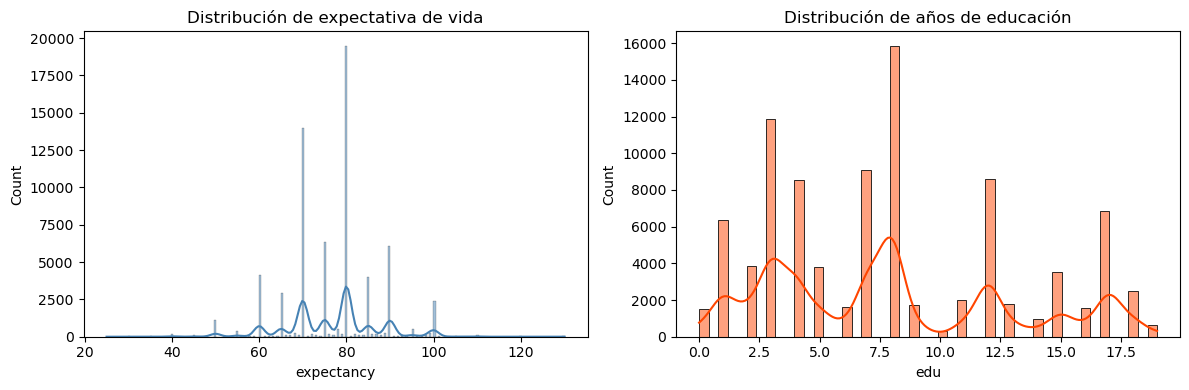

In [7]:
# Visualización de la distribución de expectativa de vida y educación, se hizo un corte en la de expectativa de vida
# para evitar el ruido que generan los valores extremos
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df[df['expectancy'] < 150]['expectancy'].dropna(), kde=True, color="steelblue")
plt.title("Distribución de expectativa de vida")

plt.subplot(1, 2, 2)
sns.histplot(df['edu'].dropna(), kde=True, color="orangered")
plt.title("Distribución de años de educación")
plt.tight_layout()
plt.show()

In [8]:
# una limpieza sencilla para eliminar filas con NA en edu o expectancy (las que más importan por ahora)
df = df.dropna(subset=['edu', 'expectancy']).copy()

# vemos el tamaño final
df.shape

(69236, 34)

**Respuesta:** Antes de todo se debe cargar la data (**panel_eps.csv**), la cual se definió como nuestro `df` a trabajar. Esta data correspondiente a la Encuesta de Protección Social, de la cual se exploraron las variables relevantes. Se identificaron inconsistencias en la variable `edad`, ya que contenía tanto edades como años de nacimiento. Para resolver esto, se utilizó la información del primer año de participación de cada individuo (`time`) y el año de la encuesta (asumiendo que la ronda 1 fue en 2002). Así, se creó una variable `edad_base` que representa la edad real en la primera ronda observada para cada persona.

Luego de esto, se revisaron ciertos valores faltantes, y se decidió eliminar la primera ronda debido a que muchas variables clave como enfermedades no estaban presentes. También se creó una variable dummy `trabajando` para facilitar análisis posteriores. Se visualizaron las distribuciones de expectativa de vida (`expectancy`) y educación (`edu`), y se eliminaron las observaciones con valores nulos en estas dos variables, dado que son centrales en el análisis. Este proceso dejó una base de datos limpia, estructurada como panel, y ya lista para las estimaciones posteriores.

<font size="3">**Pregunta 2**</font>

In [9]:
from linearmodels.panel import PooledOLS

# Variables
variables = ['edu', 'hombre', 'edad_base', 'illness', 'cronica', 'mental']

# Creamos índice panel y preparamos la data
df_pooled = df_clean[variables + ['expectancy', 'folio_n20', 'time']].dropna()
df_pooled = df_pooled.set_index(['folio_n20', 'time'])

y_pooled = df_pooled['expectancy']
X_pooled = sm.add_constant(df_pooled[variables])

# modelo Pooled OLS
modelo_pooledOLS = PooledOLS(y_pooled, X_pooled).fit()
print(modelo_pooledOLS)

                          PooledOLS Estimation Summary                          
Dep. Variable:             expectancy   R-squared:                        0.0156
Estimator:                  PooledOLS   R-squared (Between):              0.0407
No. Observations:               53535   R-squared (Within):               0.0070
Date:                Tue, May 20 2025   R-squared (Overall):              0.0156
Time:                        20:40:04   Log-likelihood                -3.699e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      141.00
Entities:                       24056   P-value                           0.0000
Avg Obs:                       2.2254   Distribution:                 F(6,53528)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             141.00
                            

**Respuesta:** Se estimó un modelo *Pooled OLS* para explicar la expectativa de vida (`expectancy`) a partir de variables como los años de educación (`edu`), género (`hombre`), edad base, y la presencia de enfermedades (`illness`, `cronica`, `mental`). Este tipo de modelo asume que no existe heterogeneidad individual no observada y que todos los efectos pueden ser capturados por las variables que se incluyen.

Los resultados muestran que a mayores años de educación, estos se asocian negativamente con la expectativa de vida, lo cual puede reflejar una correlación espuria (es decir no presentan una relación casual, aunque estén asociadas) debido a variables omitidas o problemas de medición. Las enfermedades crónicas (`cronica`) tienen un efecto positivo, mientras que tener alguna enfermedad (`illness`) tiene un efecto negativo, lo que podría reflejar problemas de multicolinealidad o interacción entre variables. También se tiene que la variable mental es significativa y positiva. Sin embargo, el $\text{R}^{2}$ del modelo es bajo (~1.5%), lo que indica que la capacidad explicativa del modelo es limitada (sospechoso, quizás no sea buen modelo). Algunas variables resultan estadísticamente significativas, pero aún así el modelo no captura adecuadamente la heterogeneidad entre individuos, lo que podría conllevar a un uso de modelos más complejos o quizás simplemente usar otro, como se hará a continuación.

<font size="3">**Pregunta 3**</font>

In [10]:
from linearmodels.panel import PanelOLS

# índice panel
df_panel = df_clean.set_index(['folio_n20', 'time'])

# solo dejamos variables que varían en el tiempo !
modelo_fe = PanelOLS.from_formula(
    'expectancy ~ edu + illness + cronica + mental + EntityEffects',
    data=df_panel
).fit(cov_type='robust')

print(modelo_fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0075
Estimator:                   PanelOLS   R-squared (Between):             -0.0763
No. Observations:               53560   R-squared (Within):               0.0075
Date:                Tue, May 20 2025   R-squared (Overall):             -0.0402
Time:                        20:40:04   Log-likelihood                -3.578e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      55.682
Entities:                       24072   P-value                           0.0000
Avg Obs:                       2.2250   Distribution:                 F(4,29484)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             48.484
                            

Para este caso se implementó un modelo de efectos fijos, que permita controlar por heterogeneidad no observada que es constante en el tiempo para cada individuo. Este modelo considera únicamente variables que varían entre periodos (como educación o salud), y elimina del análisis los efectos individuales invariables mediante una transformación dentro del grupo. En detalle, se observó que los coeficientes se mantienen, tanto para términos de signo como de significancia, especialmente para las variables relacionadas con enfermedades (`illness`, `cronica`, `mental`). Sin embargo, el efecto de la educación sigue siendo negativo y significativo, aunque de menor magnitud que en el modelo anterior (de igual forma no se ve bien para considerarlo). El $\text{R}^{2}$ dentro del modelo es muy bajo (~0.75%), lo que indica que, incluso considerando efectos fijos, el modelo tiene baja capacidad de poder predecir bein. Aun así, este enfoque es preferible al *Pooled OLS*, ya que permite corregir el sesgo de variables omitidas constantes en el tiempo.

<font size="3">**Pregunta 4**</font>

In [11]:
from linearmodels.panel import RandomEffects

modelo_re = RandomEffects.from_formula(
    'expectancy ~ edu + illness + cronica + mental',
    data=df_panel
).fit(cov_type='robust')
print(modelo_re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.2063
Estimator:              RandomEffects   R-squared (Between):              0.3516
No. Observations:               53560   R-squared (Within):              -0.0104
Date:                Tue, May 20 2025   R-squared (Overall):              0.2063
Time:                        20:40:04   Log-likelihood                -3.726e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      3480.8
Entities:                       24072   P-value                           0.0000
Avg Obs:                       2.2250   Distribution:                 F(4,53556)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             3913.3
                            

En esta parte se estimó un modelo de efectos aleatorios (RE) como alternativa al modelo de efectos fijos (FE). Este enfoque asume que la heterogeneidad individual no observada no está correlacionada con las variables explicativas, lo que permite obtener estimaciones más eficientes bajo ese supuesto. Los resultados muestran coeficientes altamente significativos para todas las variables, y los signos son, en general, consistentes con la intuición: las enfermedades (`illness`, `cronica`, `mental`) afectan la expectativa de vida de manera diferenciada, mientras que la educación (`edu`) muestra ahora un efecto positivo, a diferencia de los modelos anteriores. El $\text{R}^{2}$ overall (≈ 20%) es considerablemente mayor que en los modelos de Pooled OLS y efectos fijos, lo que indica un mejor ajuste agregado. Sin embargo, este mejor desempeño no garantiza validez causal. El cambio en el signo de `edu` sugiere que podría existir correlación entre los efectos no observados y las variables incluidas, lo cual violaría los supuestos del modelo RE. Esta posibilidad será abordada de acuerdo a lo que se verá en la siguiente sección mediante el test de Hausman.

<font size="3">**Pregunta 5**</font>

In [12]:
# Comparación de modelos
print(lmp.compare({"FE": modelo_fe, "RE": modelo_re, "Pooled": modelo_pooledOLS}))

                            Model Comparison                           
                                    FE                RE         Pooled
-----------------------------------------------------------------------
Dep. Variable               expectancy        expectancy     expectancy
Estimator                     PanelOLS     RandomEffects      PooledOLS
No. Observations                 53560             53560          53535
Cov. Est.                       Robust            Robust     Unadjusted
R-squared                       0.0075            0.2063         0.0156
R-Squared (Within)              0.0075           -0.0104         0.0070
R-Squared (Between)            -0.0763            0.3516         0.0407
R-Squared (Overall)            -0.0402            0.2063         0.0156
F-statistic                     55.682            3480.8         141.00
P-value (F-stat)                0.0000            0.0000         0.0000
=====================     ============   ===============   =====

In [13]:
import numpy.linalg as la
from scipy import stats

def hausman(fe, re):
    diff = fe.params - re.params
    psi = fe.cov - re.cov
    dof = diff.size - 1
    W = diff.dot(la.inv(psi)).dot(diff)
    pval = stats.chi2.sf(W, dof)
    return W, dof, pval

htest = hausman(modelo_fe, modelo_re)
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 499.50226429073496, df = 3, p-value = 6.116980707631247e-108


Luego de revisar los tres modelos anteriores, los cuales tratan de explicar la expectativa de vida (`expectancy`) en función de variables como educación y variables de salud, se tiene en principio que difieren en cómo tratan la heterogeneidad individual no observada principalmente. Comentaremos lo que ya se ha mencionado por cada pregunta sobre los modelos:

Por un lado el modelo Pooled OLS ignora completamente las diferencias entre individuos, lo que puede llevar a estimaciones sesgadas si existen efectos individuales correlacionados con las variables explicativas. Aunque algunos coeficientes son estadísticamente significativos, su capacidad explicativa fue baja (R² ≈ 1.5%) y el supuesto de homogeneidad es muy restrictivo, como ya se mencionó antes.

El modelo de efectos fijos mejora al controlar por características individuales invariables en el tiempo, lo que permite identificar el efecto de las variables que cambian entre rondas. Si bien el R² "within" sigue siendo bajo (≈0.75%), los coeficientes se ajustan de forma más conservadora. Este modelo es más confiable si se sospecha que las variables explicativas están correlacionadas con factores no observados del individuo (como puede ser el caso con la educación).

El modelo de efectos aleatorios, en cambio, permite incorporar esa heterogeneidad, bajo el supuesto de que no está correlacionada con las variables explicativas. Mostró un ajuste mucho mejor (R² ≈ 20.6%), con estimaciones más estables. Sin embargo, este supuesto se puede poner a duda. Para resolver esto, se aplicó el test de Hausman, el cual rechazó la hipótesis nula (p < 0.00001), indicando que existe correlación entre los efectos no observados y las variables explicativas. Esto implica que el modelo FE es más consistente y debe preferirse por sobre RE en este caso.

En cuanto a robustez, variables como `cronica`, `illness` y `mental` mantuvieron su significancia y signo en todos los modelos, lo que sugiere una relación estructural con la expectativa de vida. En cambio, `edu` mostró una notable inestabilidad, dado que pasó de tener un efecto negativo para Pooled/FE a un positivo, esto indicaria sospechas que se temian por el sesgo (en modelo RE). Por último, se debe tener en cuenta que dada la naturaleza no balanceada del panel y la posibilidad de tendencias temporales no capturadas, podría ser útil incorporar efectos fijos por tiempo (como dummies por ronda) en análisis más avanzados. Por tanto, el modelo de efectos fijos es el más adecuado para responder lo que se necesita, ya que permite obtener estimadores consistentes en presencia de heterogeneidad no observada correlacionada con las variables explicativas.

<font size="3">**Pregunta 6**</font>

In [14]:
# Modelo de efectos aleatorios correlacionados (CRE)

# Variables que se usaron antes y que se van a usar para el modelo CRE
cre_vars = ['edu', 'illness', 'cronica', 'mental']

# Se calculan promedios individuales por cada folio
for var in cre_vars:
    df_clean[f'{var}_mean'] = df_clean.groupby('folio_n20')[var].transform('mean')

# fórmula de cada variable con su promedio
cre_formula = 'expectancy ~ ' + ' + '.join(cre_vars + [f'{v}_mean' for v in cre_vars])

# Estimamos la misma relación anterior pero ahora con efectos aleatorios correlacionados
# (CRE) usando la librería linearmodels
from linearmodels.panel import RandomEffects

modelo_cre = RandomEffects.from_formula(
    cre_formula,
    data=df_clean.set_index(['folio_n20', 'time'])
).fit(cov_type='robust')

print(modelo_cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.2207
Estimator:              RandomEffects   R-squared (Between):              0.3626
No. Observations:               53560   R-squared (Within):               0.0071
Date:                Tue, May 20 2025   R-squared (Overall):              0.2207
Time:                        20:40:05   Log-likelihood                -3.721e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1896.2
Entities:                       24072   P-value                           0.0000
Avg Obs:                       2.2250   Distribution:                 F(8,53552)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             2063.4
                            

En esta ocasión se estimó un modelo de Efectos Aleatorios Correlacionados (CRE) como alternativa a los modelos anteriores. Esta técnica permite incorporar los beneficios del modelo RE, pero controlando la correlación entre los efectos individuales y las variables explicativas mediante la inclusión de los promedios individuales de cada variable. Así, el modelo permite identificar tanto los efectos dentro del individuo (cambios a lo largo del tiempo) como los efectos entre individuos (diferencias estructurales).

Como resultados, se tuvieron respuestas consistentes con el modelo FE en cuanto a los coeficientes de las variables originales, pero además permitió observar cómo el promedio de esas variables peude impactar la expectativa de vida. Para clarificar esto, es posible decir que para la "edu_mean" se tuvo un efecto positivo fuerte, pero por otro lado la `edu` tiene uno negativo. Esto sugiere que los individuos con más educación tienden a tener mayor expectativa de vida en promedio, pero dentro del mismo individuo, aumentos recientes en educación no necesariamente implican una mejora en la expectativa reportada.Esto conlleva a dar importancia sobre las distinciones de efectos a nivel -entre individuos- y -dentro del individuo-. El modelo CRE logra capturar esta heterogeneidad y provee resultados más completos que los modelos FE y RE por separado.

<font size="3">**Pregunta 7**</font>

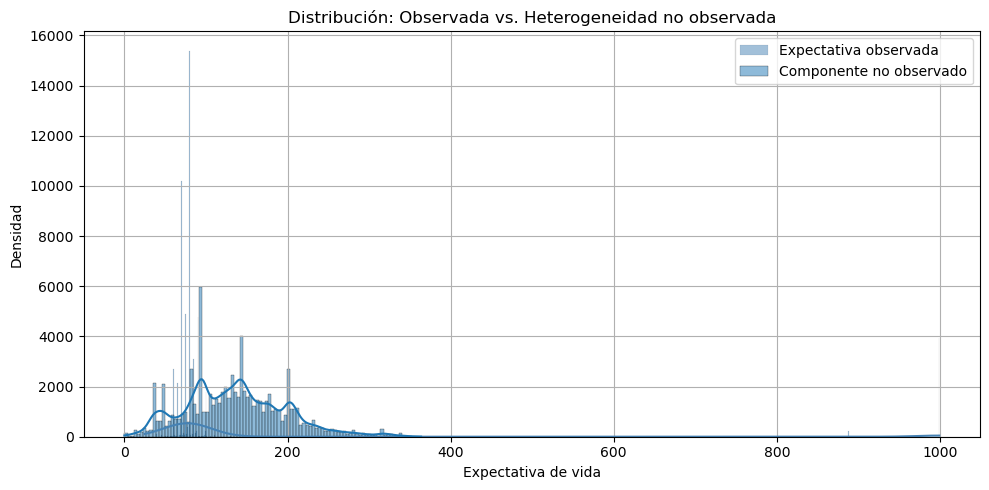

In [15]:
# Variables usadas en el modelo CRE
cre_vars = ['edu', 'illness', 'cronica', 'mental']
cre_means = [f'{v}_mean' for v in cre_vars]

# Crear DataFrame base con MultiIndex
Xpred = df_clean.set_index(['folio_n20', 'time'])[[*cre_vars, *cre_means]].copy()

# Poner en cero las variables que varían en el tiempo
for var in cre_vars:
    Xpred[var] = 0

# Predicción del componente no observado
yhat_unobserved = modelo_cre.predict(Xpred)

# Gráfico de comparación con la expectativa observada
plt.figure(figsize=(10,5))
sns.histplot(df_clean['expectancy'], color='steelblue', label='Expectativa observada', kde=True)
sns.histplot(yhat_unobserved, color='darkorange', label='Componente no observado', kde=True)
plt.title("Distribución: Observada vs. Heterogeneidad no observada")
plt.xlabel("Expectativa de vida")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Usando el modelo CRE, se estimó la distribución del componente no observado, es decir, cuánto de la expectativa de vida se explica por diferencias individuales que no cambian en el tiempo. Para eso, se fijaron en cero las variables que sí varían entre periodos (como enfermedad o educación momentánea), y se mantuvieron los promedios individuales, que capturan esa heterogeneidad fija. El gráfico muestra que esta parte no observada tiene una distribución mucho más concentrada y menos dispersa que la expectativa observada, lo que sugiere que buena parte de la variación entre personas viene de factores persistentes como el nivel educativo promedio o condiciones de salud crónicas. Esto confirma lo útil del modelo CRE, ya que permite separar los efectos que cambian en el tiempo de los que son estructurales, y entender mejor qué tan relevante es la heterogeneidad individual en este tipo de fenómenos

<font size="3">**Pregunta 8**</font>

In [17]:
# Comparación de modelos
print(lmp.compare({"FE": modelo_fe, "RE": modelo_re, "CRE": modelo_cre}))

                             Model Comparison                             
                                    FE                RE               CRE
--------------------------------------------------------------------------
Dep. Variable               expectancy        expectancy        expectancy
Estimator                     PanelOLS     RandomEffects     RandomEffects
No. Observations                 53560             53560             53560
Cov. Est.                       Robust            Robust            Robust
R-squared                       0.0075            0.2063            0.2207
R-Squared (Within)              0.0075           -0.0104            0.0071
R-Squared (Between)            -0.0763            0.3516            0.3626
R-Squared (Overall)            -0.0402            0.2063            0.2207
F-statistic                     55.682            3480.8            1896.2
P-value (F-stat)                0.0000            0.0000            0.0000
=====================    

Luego de comparar los modelos estimados, el que se prefiere es el modelo CRE (obviamente fue mejor). Este permite controlar por heterogeneidad no observada entre individuos y, a diferencia del RE, no asume independencia entre los efectos individuales y las variables explicativas. Este además, presentó un mejor ajuste (R² ≈ 22%) y posee resultados coherentes con los que se obtuvieron en el modelo de efectos fijos, lo que refuerza su validez.

Las distintas variables de salud que se utilizaron y se presentaban en esta data, poseen efectos fuertes y con mucha significancia por sobre la expectativa de vida. En algunos casos ciertas enfermedades como crónicas o mentales se pueden asociar muy fuertemente, teniendo a las crónicas como la mayor prioridad de influencia en nuestra variable principal. Cuando se tiene educación, se lleva a otro terreno, ya que también hay que distinguir si es dentro de un individuo (como aumentos en educación que reflejen un reporte de avance o no en expectativa), como también y mas importante, a nivel estructural, lo que quiere decir que, en base, las personas con mayor educación tienden a tener una mayor expectativa de vida. Es por eso que se debe modelar adecuadamente cuando existe heterogeneidad no observada, ya que esto nos permitirá hacer mejores inferencias y predicciones, y por tanto, un trabajo más realista y adecuado.